In [6]:
import pandas as pd 
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
np.random.seed(42)
data = {
    "study_hours" : [3,5,6,7,2,8,1,5,4,3],
    "Assignment_marks" : np.random.randint(20,31,10),
    "iq" : np.round(np.random.uniform(1,6,10),2),
    "Total_marks": np.random.randint(40,100,10)
}

In [8]:
df = pd.DataFrame(data)

In [9]:
df.head()

,study_hours,Assignment_marks,iq,Total_marks
0,3,26,3.30,97
1,5,23,2.67,61
2,6,30,1.71,83
3,7,27,4.25,64
4,2,24,1.28,88


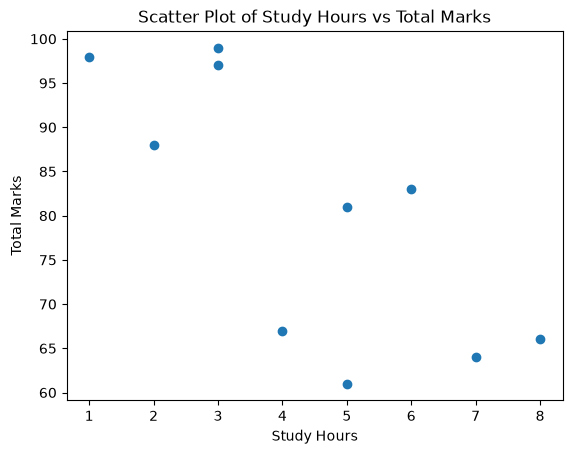

In [10]:
plt.scatter(df["study_hours"], df["Total_marks"])
plt.xlabel("Study Hours")
plt.ylabel("Total Marks")
plt.title("Scatter Plot of Study Hours vs Total Marks")
plt.show()

<Axes: >

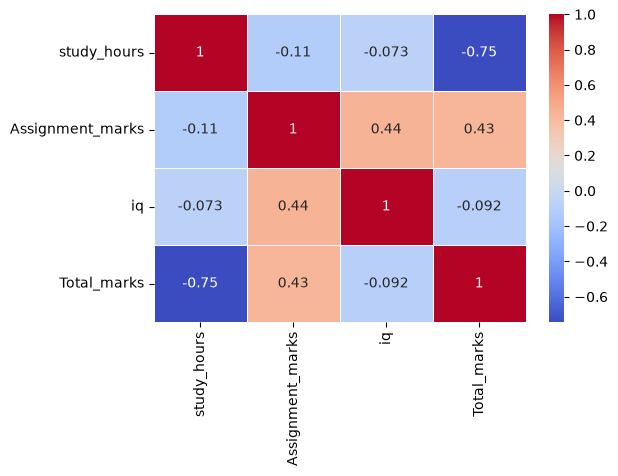

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths= 0.5)

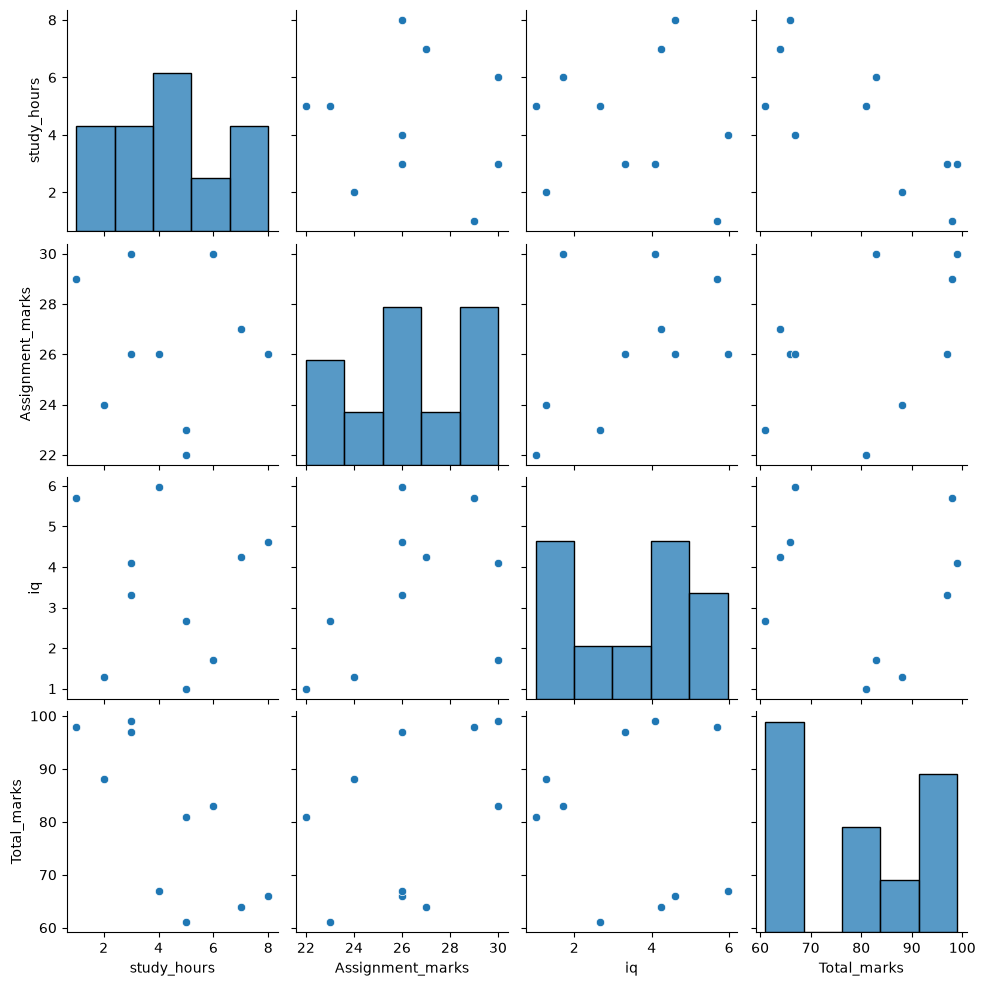

In [32]:
sns.pairplot(df)

In [15]:
x = df.drop(columns="Total_marks")
y = df['Total_marks']
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [16]:
model = LinearRegression()

In [17]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-5.24, 1.68,-1.95]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['study_hours','Assignment_marks','iq']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,68.17
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [26]:
pred = model.predict([[4, 25, 3.5]])
print(pred[0])

82.38954788773394


c:\Users\Anuj Kumar\Desktop\Machine Learning\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [31]:
y_pred = model.predict(x_test)
print("Predicted values:")
for i in y_pred:
    print(f"{i:.2f}")

Predicted values:
79.28
75.41
60.95


Text(0.5, 0, 'Study Hours')

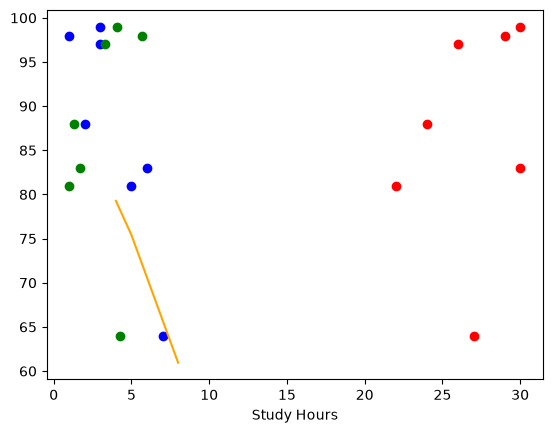

In [44]:
plt.scatter(x_train["study_hours"], y_train, color='blue', label='Training Data')
plt.scatter(x_train["iq"], y_train, color='green', label='Testing Data')
plt.scatter(x_train["Assignment_marks"], y_train, color='red', label='Predicted    Data')
plt.plot(x_test["study_hours"], y_pred, color='orange', label='Regression Line')
plt.xlabel("Study Hours")

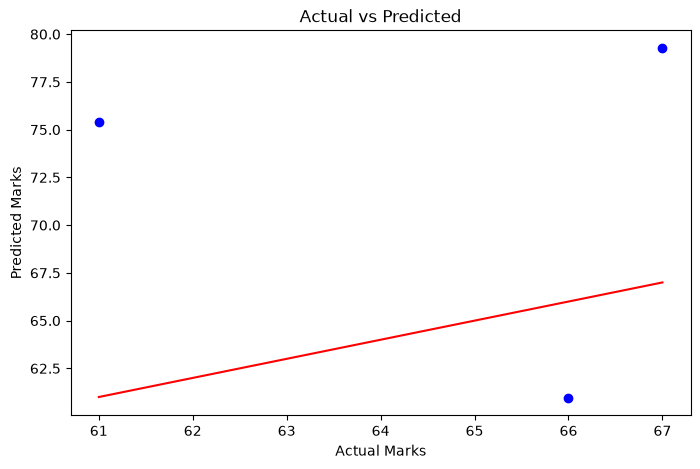

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, color='blue')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()

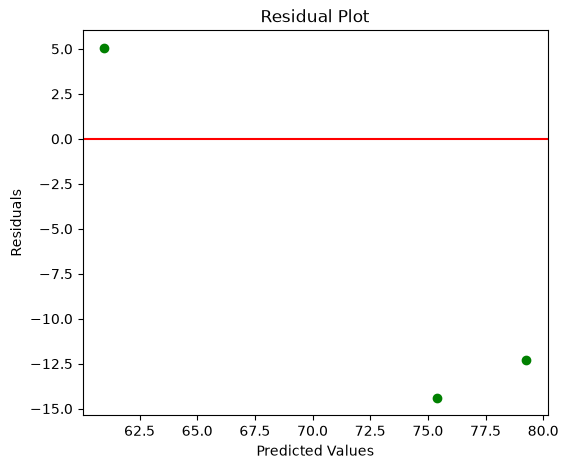

In [46]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred, residuals, color='green')

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

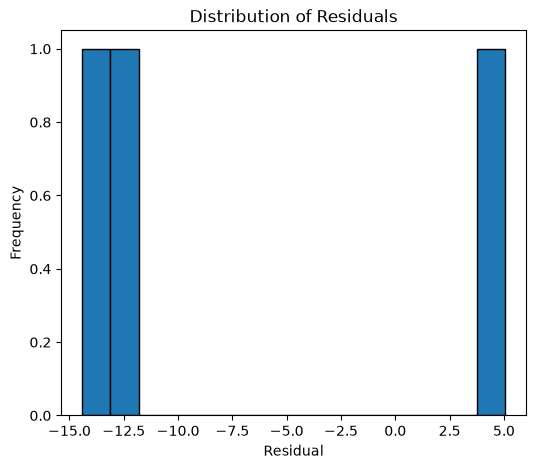

In [47]:
plt.figure(figsize=(6,5))

plt.hist(residuals, bins=15, edgecolor='black')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()